In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments
from peft import LoraConfig, get_peft_model, TaskType
from datasets import load_dataset

In [3]:
# Load pre-trained LLaMA model (small for demo)
# model_name = "decapoda-research/llama-7b-hf"
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")


In [4]:
#  Apply LoRA for efficient fine-tuning
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
)
model = get_peft_model(model, lora_config)

In [5]:

# 3️⃣ Load dataset
dataset = load_dataset("json", data_files="iot_dataset.json")

In [6]:
# Convert to LLM input-output format
def preprocess(example):
    text = f"Sensor readings: {example['input']} => Action: {example['output']}"
    tokenized = tokenizer(text, truncation=True, max_length=128)
    tokenized["labels"] = tokenized["input_ids"].copy()
    return tokenized

tokenized_dataset = dataset.map(preprocess, batched=False)


In [7]:

# Training setup
training_args = TrainingArguments(
    output_dir="./llama_iot_demo",
    per_device_train_batch_size=1,  # adjust for GPU memory
    num_train_epochs=3,
    learning_rate=3e-4,
    logging_steps=5,
    fp16=True,
    save_steps=50,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
)

# 6️⃣ Train
trainer.train()


  0%|          | 0/30 [00:00<?, ?it/s]

{'loss': 3.0731, 'grad_norm': 2.9476876258850098, 'learning_rate': 0.00025, 'epoch': 0.5}
{'loss': 2.5034, 'grad_norm': 3.227886199951172, 'learning_rate': 0.00019999999999999998, 'epoch': 1.0}
{'loss': 2.1142, 'grad_norm': 3.152759075164795, 'learning_rate': 0.00015, 'epoch': 1.5}
{'loss': 1.7411, 'grad_norm': 3.144606113433838, 'learning_rate': 9.999999999999999e-05, 'epoch': 2.0}
{'loss': 1.4593, 'grad_norm': 3.9633841514587402, 'learning_rate': 4.9999999999999996e-05, 'epoch': 2.5}
{'loss': 1.3527, 'grad_norm': 3.0458931922912598, 'learning_rate': 0.0, 'epoch': 3.0}
{'train_runtime': 139.7784, 'train_samples_per_second': 0.215, 'train_steps_per_second': 0.215, 'train_loss': 2.0406286398569744, 'epoch': 3.0}


TrainOutput(global_step=30, training_loss=2.0406286398569744, metrics={'train_runtime': 139.7784, 'train_samples_per_second': 0.215, 'train_steps_per_second': 0.215, 'total_flos': 9898635497472.0, 'train_loss': 2.0406286398569744, 'epoch': 3.0})

In [ ]:
# ============================================================
# BEFORE vs AFTER comparison 
# ============================================================
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

test_prompt = """Sensor readings:
Node 1: CPU 90%, RAM 80%, Temp 82C, Latency 220ms
=> Action:"""

# --- AFTER: your fine-tuned model (already loaded as `model`) ---
inputs = tokenizer(test_prompt, return_tensors="pt").to(model.device)
ft_output = model.generate(**inputs, max_new_tokens=60, temperature=0.5)
ft_text = tokenizer.decode(ft_output[0], skip_special_tokens=True)

# --- BEFORE: reload the BASE model (no LoRA weights) ---
base_model = AutoModelForCausalLM.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0", device_map="auto"
)
base_inputs = tokenizer(test_prompt, return_tensors="pt").to(base_model.device)
base_output = base_model.generate(**base_inputs, max_new_tokens=60, temperature=0.5)
base_text = tokenizer.decode(base_output[0], skip_special_tokens=True)

# --- Print side by side ---
print("=" * 60)
print("INPUT:")
print(test_prompt)
print("=" * 60)
print("BASE MODEL (no fine-tuning):")
print(base_text.split("=> Action:")[-1].strip())
print("-" * 60)
print("FINE-TUNED MODEL:")
print(ft_text.split("=> Action:")[-1].strip())
print("=" * 60)

In [8]:
prompt = """
Sensor readings:
Node 1: CPU 90%, RAM 80%, Temp 82C, Latency 220ms
=> Action:
"""

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens=60,
    temperature=0.5
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))


/home/iqujeff/anaconda3/envs/openai/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.5` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(



Sensor readings:
Node 1: CPU 90%, RAM 80%, Temp 82C, Latency 220ms
=> Action:
- Increase CPU utilization by 10%
- Decrease RAM utilization by 10%
- Increase network latency by 20ms

Node 2: CPU 80%, RAM 70%, Temp 75C,


In [9]:
prompt = """
Sensor readings:
Node 1: CPU 90%, RAM 80%, Temp 82C, Latency 220ms

Instructions: 
1. Provide a list of recommended actions.
2. Explain why.
3. Stop after Node 1 actions.
"""

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens=60,
    temperature=0.5
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))



Sensor readings:
Node 1: CPU 90%, RAM 80%, Temp 82C, Latency 220ms

Instructions: 
1. Provide a list of recommended actions.
2. Explain why.
3. Stop after Node 1 actions.
4. Repeat for remaining nodes.
5. Provide a summary of the overall performance.

Action 1: CPU 90%, RAM 80%, Temp 82C, Latency 220ms
- Node 1: Increase CPU


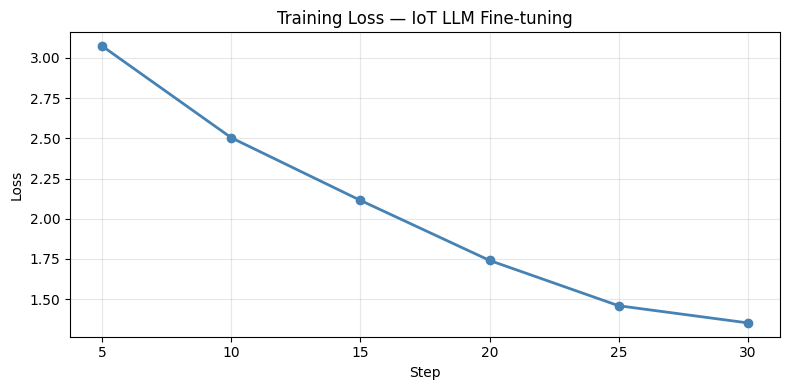

Start loss: 3.0731
Final loss: 1.3527
Improvement: 56.0%


In [12]:
import matplotlib.pyplot as plt

# Extract training loss from log history
log_history = trainer.state.log_history

# Pull out steps and loss values (filter only entries that have 'loss')
train_losses = [(entry['step'], entry['loss']) 
                for entry in log_history 
                if 'loss' in entry]

steps  = [x[0] for x in train_losses]
losses = [x[1] for x in train_losses]

# Plot
plt.figure(figsize=(8, 4))
plt.plot(steps, losses, marker='o', linewidth=2, color='steelblue')
plt.title('Training Loss — IoT LLM Fine-tuning')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()

print(f"Start loss: {losses[0]:.4f}")
print(f"Final loss: {losses[-1]:.4f}")
print(f"Improvement: {((losses[0] - losses[-1]) / losses[0] * 100):.1f}%")